<a href="https://colab.research.google.com/github/fabriciosantana/mcdia/blob/main/m1_a2_nb1_Riscos_XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise de Riscos usando Inteligência Artificial - Boosted Trees**
# PARTE 1: Preparação dos Dados e Feature Engineering

Este notebook corresponde à primeira parte de um exercício prático, focando na preparação e engenharia de atributos (Feature Engineering) para um modelo de análise de risco baseado em árvores impulsionadas (Boosted Trees). O objetivo é transformar os dados brutos em um formato adequado para o treinamento do modelo, extraindo informações relevantes e tratando possíveis problemas nos dados.

## **Setup Inicial do ambiente**

### Importando a biblioteca disponibilizada com git

**Variáveis Discretas e Categóricas**

Para as variáveis discretas (como as `qtd`s, que representam contagens) e categóricas (como `cat1`, `cat2`, `cat3`, que representam categorias ou grupos), o histograma não é a ferramenta mais adequada. Em vez disso, usaremos gráficos de barras para representar a tabela de frequências. Esses gráficos nos permitem visualizar a distribuição de cada categoria ou valor discreto, identificando quais são os mais ou menos frequentes.

### Montando o Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/My Drive/_TASKS/202607 - IDP - Auditoria com dados'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Imports

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import json

## **Engenharia de Atributos (*Feature Engineering*)**

A Engenharia de Atributos é uma etapa crucial no desenvolvimento de modelos de Machine Learning, especialmente em cenários de análise de risco. Nesta fase, transformamos os dados brutos em variáveis (atributos ou *features*) que o modelo pode utilizar para aprender padrões e fazer previsões mais precisas. Isso pode envolver a criação de novas variáveis, a transformação de variáveis existentes ou a combinação de informações de diferentes fontes.

Para esta aula, usaremos um dataset mascarado gerado a partir de dados reais de uma situação de análise de risco. Embora os nomes das colunas sejam genéricos (ex: v1, bin1, qtd1, cat1), eles representam informações valiosas que serão processadas para criar atributos mais robustos.

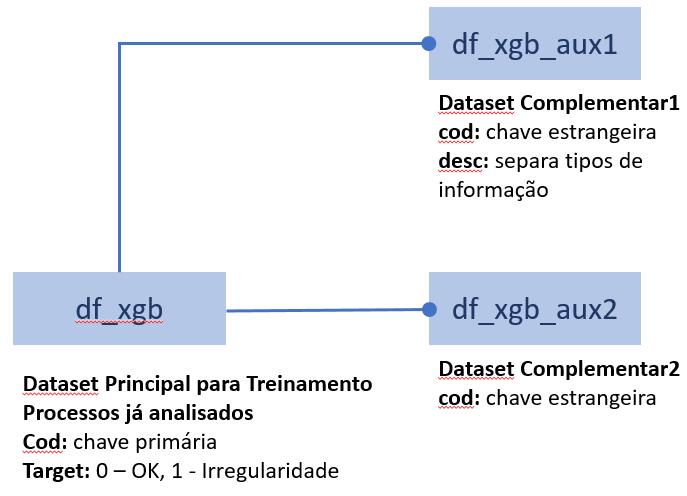

### Obtendo o dataset principal

In [28]:
df = pd.read_pickle(os.path.join(DATA_PATH,'df_xgb.pkl'))
df

resultado_carregar_dataset = {
    "transaction": "carregar-dataset",
    "qtd_rows": len(df),
    "qtd_columns": len(df.columns),
    "columns": df.columns,
    "message": "Dataset carregado com sucesso"
}

log = json.dumps(
    resultado_carregar_dataset,
    ensure_ascii=False,
    indent=2,
    default=str
)

print(log)
df


{
  "transaction": "carregar-dataset",
  "qtd_rows": 24285,
  "qtd_columns": 54,
  "columns": "Index(['v1', 'v2', 'bin1', 'bin2', 'bin3', 'bin4', 'bin5', 'bin6', 'bin7',\n       'bin8', 'bin9', 'bin10', 'bin11', 'bin12', 'bin13', 'bin14', 'bin15',\n       'bin16', 'bin17', 'bin18', 'bin19', 'bin20', 'bin21', 'bin22', 'bin23',\n       'bin24', 'bin25', 'bin26', 'bin27', 'bin28', 'bin29', 'bin30', 'bin31',\n       'qtd1', 'qtd2', 'qtd3', 'qtd4', 'qtd5', 'qtd6', 'qtd7', 'qtd8', 'qtd9',\n       'qtd10', 'qtd11', 'qtd12', 'qtd13', 'qtd14', 't1', 't2', 'target',\n       'cod', 'cat1', 'cat2', 'cat3'],\n      dtype='object')",
  "message": "Dataset carregado com sucesso"
}


,v1,v2,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,qtd12,qtd13,qtd14,t1,t2,target,cod,cat1,cat2,cat3
37,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.114990,0.210815,0,261.0,2,1,1
53,1075.14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.114990,0.210815,0,289.0,2,1,1
61,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.114990,0.158795,0,297.0,2,1,1
64,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.134155,0.136893,0,301.0,2,1,1
71,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.134155,0.164271,0,308.0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508164,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.752909,0.052019,0,551973.0,2,1,2
508594,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.514716,0.049281,0,552421.0,2,1,2
510168,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,2.776181,0.002738,0,554772.0,2,2,2
512324,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,2.357290,0.002738,0,557051.0,1,2,2


In [29]:
orig_cols = df.columns
orig_cols

Index(['v1', 'v2', 'bin1', 'bin2', 'bin3', 'bin4', 'bin5', 'bin6', 'bin7',
       'bin8', 'bin9', 'bin10', 'bin11', 'bin12', 'bin13', 'bin14', 'bin15',
       'bin16', 'bin17', 'bin18', 'bin19', 'bin20', 'bin21', 'bin22', 'bin23',
       'bin24', 'bin25', 'bin26', 'bin27', 'bin28', 'bin29', 'bin30', 'bin31',
       'qtd1', 'qtd2', 'qtd3', 'qtd4', 'qtd5', 'qtd6', 'qtd7', 'qtd8', 'qtd9',
       'qtd10', 'qtd11', 'qtd12', 'qtd13', 'qtd14', 't1', 't2', 'target',
       'cod', 'cat1', 'cat2', 'cat3'],
      dtype='object')

### Obtendo e analisando os datasets complementares

#### **df_aux1**

In [30]:
df_aux1 = pd.read_pickle(os.path.join(DATA_PATH,'df_xgb_aux1.pkl'))
df_aux1

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/_TASKS/202607 - IDP - Auditoria com dados/df_xgb_aux1.pkl'

A quantidade de ocorrências das descrições qtd15, qtd16, qtd17 para cada código pode ser uma informação relevante. Como na amostra acima, apenas aparecem qtd15 e qtd16, vamos analisar com mais detalhes a distribuição dessas descrições para entender quais são as mais frequentes e como elas se comportam no dataset auxiliar.

In [ ]:
df_aux1.desc.value_counts()

,count
desc,
qtd16,34149
qtd15,10846
qtd17,95


#### **df_aux2**

In [ ]:
df_aux2 = pd.read_pickle(os.path.join(DATA_PATH,'df_xgb_aux2.pkl'))
df_aux2

,cod,occurs
0,321.0,0
1,321.0,1
0,383.0,0
1,383.0,1
0,385.0,0
...,...,...
0,551973.0,0
0,552421.0,0
0,554772.0,0
0,557051.0,0


Aqui apenas a quantidade de simples ocorrência na tabela para cada codigo representa a informação que queremos.

### **1o. Passo: Desnormalização e identificação de novas variáveis**

Nosso dataset principal (`df`) contém as informações primárias de cada transação (identificada por `cod`). No entanto, temos informações adicionais em tabelas auxiliares (`df_aux1` e `df_aux2`) que precisam ser incorporadas ao `df` para enriquecer nossos atributos. Este processo de combinação de dados de múltiplas tabelas em uma única tabela plana é conhecido como *desnormalização*.

Precisamos transformar os dados para ficarmos com um dataset único com apenas uma linha por transação (código `cod`).

#### **Incorporando a tabela auxiliar 2 (`df_aux2`)**

Começaremos pela `df_aux2` porque ela é mais simples, contendo apenas o `cod` e uma coluna de `occorrs` (ocorrências).

Contaremos as ocorrências por código, usando o `groupby` do Pandas. Isso nos dará uma contagem agregada de `occorrs` para cada `cod` presente em `df_aux2`.

In [ ]:
df_aux2_grp = df_aux2.groupby(['cod']).count().reset_index()
df_aux2_grp

,cod,occurs
0,321.0,2
1,383.0,2
2,385.0,2
3,542.0,1
4,841.0,1
...,...,...
19541,551973.0,1
19542,552421.0,1
19543,554772.0,1
19544,557051.0,1


Com o `df_aux2_grp`, agora temos uma linha única para cada `cod` com a contagem total de ocorrências. Este é o formato ideal para realizar o `merge` (junção) com o nosso dataframe principal (`df`), adicionando esta nova informação como um atributo.

In [ ]:
df_merge = df.merge(df_aux2_grp, how='left', on = 'cod')
df_merge

,v1,v2,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,qtd13,qtd14,t1,t2,target,cod,cat1,cat2,cat3,occurs
0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.114990,0.210815,0,261.0,2,1,1,NaN
1,1075.14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.114990,0.210815,0,289.0,2,1,1,NaN
2,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.114990,0.158795,0,297.0,2,1,1,NaN
3,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.134155,0.136893,0,301.0,2,1,1,NaN
4,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.134155,0.164271,0,308.0,2,1,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24280,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.752909,0.052019,0,551973.0,2,1,2,1.0
24281,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.514716,0.049281,0,552421.0,2,1,2,1.0
24282,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2.776181,0.002738,0,554772.0,2,2,2,1.0
24283,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2.357290,0.002738,0,557051.0,1,2,2,1.0


Vamos renomear a coluna `occurs` para `qtd18`. Essa renomeação é importante para dar um nome mais descritivo e específico ao novo atributo, evitando conflitos de nomes caso outra coluna chamada 'occurs' seja introduzida, e também para padronizar a nomenclatura das quantidades (qtd).

In [ ]:
df_merge = df_merge.rename(columns = {'occurs': 'qtd18'})
df_merge.head(10)


,v1,v2,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,qtd13,qtd14,t1,t2,target,cod,cat1,cat2,cat3,qtd18
0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.114990,0.210815,0,261.0,2,1,1,NaN
1,1075.14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.114990,0.210815,0,289.0,2,1,1,NaN
2,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.114990,0.158795,0,297.0,2,1,1,NaN
3,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.134155,0.136893,0,301.0,2,1,1,NaN
4,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.134155,0.164271,0,308.0,2,1,1,NaN
5,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.136893,0.188912,0,321.0,2,1,1,2.0
6,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.136893,0.139630,0,323.0,2,1,1,NaN
7,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.251882,0.136893,0,383.0,2,1,1,2.0
8,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.251882,0.136893,0,385.0,2,1,1,2.0
9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.093087,0.142368,0,542.0,2,1,1,1.0


Observamos que, após o merge, a nova coluna `qtd18` apresenta valores nulos (NaN) para alguns códigos. Isso ocorre quando um `cod` presente no `df` principal não possui correspondência no `df_aux2_grp` (ou seja, não houve ocorrências para aquele código na tabela auxiliar 2). Não iremos nos preocupar com esses nulos por enquanto; mais adiante, cuidaremos deles de forma sistemática.

#### **Incorporando a tabela auxiliar 1 (`df_aux1`)**

Como vimos na análise inicial, a `df_aux1` contém informações mais detalhadas sobre diferentes tipos de ocorrências (`qtd15`, `qtd16`, `qtd17`) associadas a cada código (`cod`). Para cada `cod`, podemos extrair o número de vezes que cada uma dessas `desc` (descrições) aparece. Nosso objetivo é criar três novas colunas no `df_merge` (`qtd15`, `qtd16`, `qtd17`), cada uma representando a contagem de suas respectivas descrições para cada `cod`.

In [ ]:
df_aux1.head(10)

,cod,occurs,desc
0,321.0,0,qtd16
1,321.0,1,qtd16
0,383.0,0,qtd16
1,383.0,1,qtd16
0,385.0,0,qtd16
1,385.0,1,qtd16
0,542.0,0,qtd16
0,841.0,0,qtd16
0,1382.0,0,qtd16
1,1382.0,1,qtd16


Após observar as primeiras linhas de `df_aux1`, pode parecer que apenas `qtd16` está presente. No entanto, para ter certeza da distribuição real de `desc` (descrições) e evitar conclusões precipitadas baseadas em uma amostra limitada, é crucial verificar a contagem de valores de toda a coluna `df_aux1.desc` usando `value_counts()`.

In [ ]:
df_aux1.desc.value_counts()

,count
desc,
qtd16,34149
qtd15,10846
qtd17,95


Conforme a `value_counts()` confirmou, as três descrições (`qtd15`, `qtd16`, `qtd17`) realmente existem, embora `qtd16` seja a mais frequente. Para incorporar essas informações ao `df_merge`, precisamos processar cada tipo de `desc` individualmente.

Usaremos o `groupby` para contar as ocorrências de `occurs` para cada `cod` *apenas para uma `desc` específica*. Por isso, antes de agrupar, precisamos filtrar o dataframe auxiliar pelo tipo de ocorrência que queremos extrair em cada momento.

Primeiro, vamos extrair as ocorrências para `qtd15`:

In [ ]:
df_aux1_qtd15_grp = df_aux1[df_aux1.desc=='qtd15'][['cod','occurs']].groupby(['cod']).count().reset_index()
df_aux1_qtd15_grp

,cod,occurs
0,2089.0,1
1,2382.0,1
2,3665.0,1
3,3669.0,1
4,3671.0,1
...,...,...
7764,547810.0,1
7765,549931.0,1
7766,549941.0,1
7767,557051.0,1


Agora que temos o `df_aux1_qtd15_grp`, que contém a contagem de `qtd15` por `cod`, podemos mesclar essa informação ao nosso dataframe principal (`df_merge`). Após o merge, renomearemos a coluna `occurs` para `qtd15` para manter a consistência na nomenclatura dos novos atributos.

In [ ]:
df_merge = df_merge.merge(df_aux1_qtd15_grp, how='left', on = 'cod')
df_merge = df_merge.rename(columns = {'occurs': 'qtd15'})
df_merge.head(10)

,v1,v2,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,qtd14,t1,t2,target,cod,cat1,cat2,cat3,qtd18,qtd15
0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.114990,0.210815,0,261.0,2,1,1,NaN,NaN
1,1075.14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.114990,0.210815,0,289.0,2,1,1,NaN,NaN
2,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.114990,0.158795,0,297.0,2,1,1,NaN,NaN
3,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.134155,0.136893,0,301.0,2,1,1,NaN,NaN
4,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.134155,0.164271,0,308.0,2,1,1,NaN,NaN
5,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.136893,0.188912,0,321.0,2,1,1,2.0,NaN
6,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.136893,0.139630,0,323.0,2,1,1,NaN,NaN
7,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.251882,0.136893,0,383.0,2,1,1,2.0,NaN
8,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.251882,0.136893,0,385.0,2,1,1,2.0,NaN
9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.093087,0.142368,0,542.0,2,1,1,1.0,NaN


### **Exercício: Código genérico para qtd15, qtd16 e qtd17**

Nos dois passos anteriores, adicionamos ao `df_merge` apenas a coluna `qtd15`. O código para extrair e mesclar `qtd16` e `qtd17` é muito similar. Para otimizar e tornar o processo mais eficiente, o objetivo deste exercício é criar um código único e genérico que possa ser reutilizado para adicionar todas as três colunas (`qtd15`, `qtd16` e `qtd17`) em um único bloco de execução. Isso demonstra como podemos aplicar loops para automatizar tarefas repetitivas em engenharia de atributos.

Inicialmente, para podermos refazer o processo de forma genérica, vamos remover a coluna `qtd15` que foi adicionada anteriormente.

In [ ]:
del df_merge['qtd15']
df_merge

,v1,v2,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,qtd13,qtd14,t1,t2,target,cod,cat1,cat2,cat3,qtd18
0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.114990,0.210815,0,261.0,2,1,1,NaN
1,1075.14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.114990,0.210815,0,289.0,2,1,1,NaN
2,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.114990,0.158795,0,297.0,2,1,1,NaN
3,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.134155,0.136893,0,301.0,2,1,1,NaN
4,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.134155,0.164271,0,308.0,2,1,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24280,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.752909,0.052019,0,551973.0,2,1,2,1.0
24281,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.514716,0.049281,0,552421.0,2,1,2,1.0
24282,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2.776181,0.002738,0,554772.0,2,2,2,1.0
24283,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2.357290,0.002738,0,557051.0,1,2,2,1.0


Agora, substitua as duas células de código anteriores (que extraíam e mesclavam apenas `qtd15`) por uma única célula com um loop. Este loop irá iterar sobre as strings `['qtd15','qtd16','qtd17']`, realizando os passos de filtragem, agrupamento, merge e renomeação para cada uma delas. Isso resultará na adição das três novas colunas de forma programática.

In [ ]:
for qtd in ['qtd15','qtd16','qtd17']:
    df_aux1_qtd_grp = df_aux1[df_aux1.desc==qtd][['cod','occurs']].groupby(['cod']).count().reset_index()
    df_merge = df_merge.merge(df_aux1_qtd_grp, how='left', on = 'cod')
    df_merge = df_merge.rename(columns = {'occurs': qtd})
df_merge.head(10)



,v1,v2,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,t2,target,cod,cat1,cat2,cat3,qtd18,qtd15,qtd16,qtd17
0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.210815,0,261.0,2,1,1,NaN,NaN,NaN,NaN
1,1075.14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.210815,0,289.0,2,1,1,NaN,NaN,NaN,NaN
2,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.158795,0,297.0,2,1,1,NaN,NaN,NaN,NaN
3,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.136893,0,301.0,2,1,1,NaN,NaN,NaN,NaN
4,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.164271,0,308.0,2,1,1,NaN,NaN,NaN,NaN
5,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.188912,0,321.0,2,1,1,2.0,NaN,2.0,NaN
6,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.139630,0,323.0,2,1,1,NaN,NaN,NaN,NaN
7,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.136893,0,383.0,2,1,1,2.0,NaN,2.0,NaN
8,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.136893,0,385.0,2,1,1,2.0,NaN,2.0,NaN
9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.142368,0,542.0,2,1,1,1.0,NaN,1.0,NaN


### **Tratamento de valores faltantes (*Missing Values*)**

Valores faltantes (ou nulos) são um problema comum em datasets e podem afetar significativamente o desempenho e a robustez dos modelos de Machine Learning. É crucial verificar junto aos especialistas de domínio qual o significado de cada valor nulo, pois um `NaN` pode ter diferentes interpretações dependendo do contexto. Tratá-los adequadamente é fundamental, pois modelos podem interpretar nulos de forma indesejada ou simplesmente falhar se não forem tratados.

As opções para tratamento de valores nulos são as seguintes:

*   **Remoção da linha:** Se o valor nulo for inesperado, raro ou indicar uma falha crítica no registro de dados, remover a linha inteira pode ser uma opção. Contudo, isso pode levar à perda de informações valiosas.

*   **Imputação com valor determinado:** Se o nulo for um valor esperado e tiver um significado específico (como 'ausência de ocorrência', 'não aplicável'), considere substituí-lo por um valor fixo, como zero (para valores numéricos) ou uma nova categoria (para dados categóricos).

*   **Imputação pela média, mediana, ou moda:** Para variáveis contínuas, é comum substituir os nulos por alguma estatística da coluna (média para distribuições simétricas, mediana para distribuições assimétricas ou moda para valores mais frequentes). Isso ajuda a preservar a distribuição da variável.

*   **Modelos preditivos:** É uma forma mais sofisticada de imputação, onde um modelo de Machine Learning é treinado com os valores não nulos de outras variáveis para prever os valores faltantes. Embora mais complexo, pode ser mais preciso.

Inicialmente, vamos verificar quais colunas do nosso dataset (`df_merge`) possuem valores nulos e a quantidade de cada um, para entender a extensão do problema.

In [ ]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24285 entries, 0 to 24284
Data columns (total 58 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   v1      24285 non-null  float64
 1   v2      24285 non-null  float64
 2   bin1    24285 non-null  float64
 3   bin2    24285 non-null  float64
 4   bin3    24285 non-null  float64
 5   bin4    24285 non-null  float64
 6   bin5    24285 non-null  float64
 7   bin6    24285 non-null  float64
 8   bin7    24285 non-null  float64
 9   bin8    24285 non-null  float64
 10  bin9    24285 non-null  float64
 11  bin10   24285 non-null  float64
 12  bin11   24285 non-null  float64
 13  bin12   24285 non-null  float64
 14  bin13   24285 non-null  float64
 15  bin14   24285 non-null  float64
 16  bin15   24285 non-null  float64
 17  bin16   24285 non-null  float64
 18  bin17   24285 non-null  float64
 19  bin18   24285 non-null  float64
 20  bin19   24285 non-null  float64
 21  bin20   24285 non-null  float64
 22

Apenas as colunas que adicionamos ao dataset (qtd15, qtd16, qtd17 e qtd18) possuem valores nulos.

Neste caso, nós sabemos o significado do valor nulo. Quando não existe ocorrência do valor na tabela auxiliar, significa que o número de ocorrências daquela quantidade é zero para aquele código.

Então, usaremos o fillna do pandas:

In [ ]:
df_merge[['qtd15', 'qtd16', 'qtd17', 'qtd18']] = df_merge[['qtd15', 'qtd16', 'qtd17', 'qtd18']].fillna(0)

In [ ]:
df_merge

,v1,v2,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,t2,target,cod,cat1,cat2,cat3,qtd18,qtd15,qtd16,qtd17
0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.210815,0,261.0,2,1,1,0.0,0.0,0.0,0.0
1,1075.14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.210815,0,289.0,2,1,1,0.0,0.0,0.0,0.0
2,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.158795,0,297.0,2,1,1,0.0,0.0,0.0,0.0
3,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.136893,0,301.0,2,1,1,0.0,0.0,0.0,0.0
4,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.164271,0,308.0,2,1,1,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24280,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.052019,0,551973.0,2,1,2,1.0,0.0,1.0,0.0
24281,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.049281,0,552421.0,2,1,2,1.0,0.0,1.0,0.0
24282,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.002738,0,554772.0,2,2,2,1.0,0.0,1.0,0.0
24283,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.002738,0,557051.0,1,2,2,1.0,1.0,1.0,0.0


### **Análise Exploratória (*Exploratory Data Analysis - EDA*)**

A Análise Exploratória de Dados (EDA) é um processo fundamental e iterativo que visa compreender a estrutura, padrões e anomalias presentes no nosso dataset. Antes de construir qualquer modelo, é importante conhecermos nossos dados em profundidade para podermos definir os próximos passos de *Feature Engineering*, identificar potenciais problemas e tomar decisões de design mais assertivas para o modelo que iremos construir. A EDA gera diversos *insights* valiosos sobre o problema em questão e sobre o comportamento das variáveis.

#### **Análise Univariada**

Começaremos analisando cada variável individualmente (`univariada`), de acordo com seu tipo (contínua ou discreta/categórica).

**Variáveis Contínuas**

Para as variáveis contínuas, como `v1`, `v2`, `t1`, `t2`, usaremos histogramas. Histogramas são gráficos que mostram a distribuição de frequência de uma variável, permitindo visualizar a forma da distribuição, a dispersão, a presença de picos (modas) e se há assimetria (skewness) nos dados.

In [ ]:
linhas, colunas = 1, 4
variaveis = ['v1', 'v2', 't1', 't2']

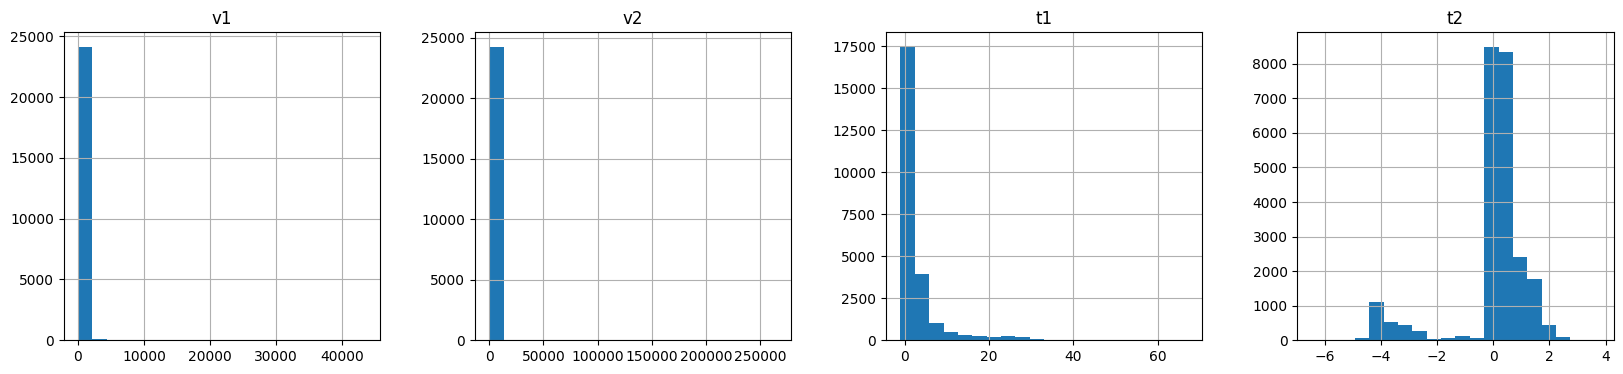

In [ ]:
fig, axs = plt.subplots(linhas, colunas, figsize=(20, 4)) #, sharex='col', sharey='row')

for var, ax in zip(variaveis, axs.flat):

    df_merge.hist(column = var, bins = 20, ax=ax) #, figsize=(20, 18))

As variáveis `v1` e `v2` possuem uma distribuição muito concentrada nos valores mais baixos (distribuição fortemente assimétrica ou `skewed`). Modelos de Machine Learning, especialmente alguns que assumem normalidade, podem ter seu desempenho prejudicado por variáveis altamente assimétricas. Para mitigar isso e tentar *normalizar* a distribuição, tentaremos aplicar uma transformação logarítmica (`log(x+1)`) nessas variáveis. O `+1` é adicionado para lidar com possíveis valores zero, já que o logaritmo de zero é indefinido.

In [ ]:
import numpy as np
df_merge['v1_log'] = np.log(df_merge.v1+1)
df_merge['v2_log'] = np.log(df_merge.v2+1)

df_merge.v1.skew(), df_merge.v1_log.skew(), df_merge.v2.skew(), df_merge.v2_log.skew()

(np.float64(29.607752616159775),
 np.float64(7.168737547113445),
 np.float64(67.14925523218797),
 np.float64(6.753709894161646))

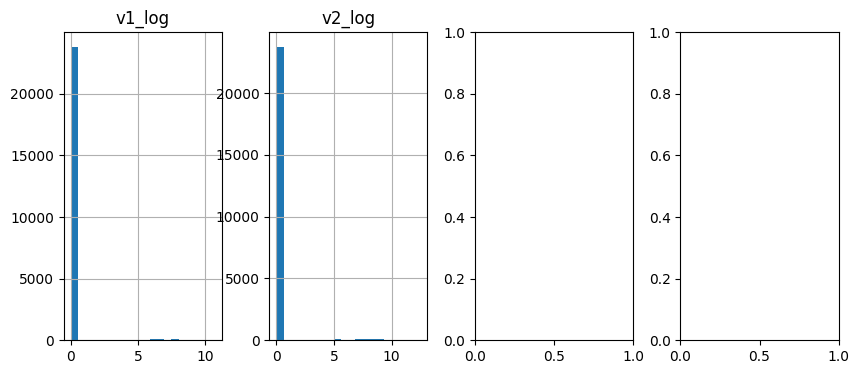

In [ ]:
variaveis = ['v1_log', 'v2_log']
fig, axs = plt.subplots(linhas, colunas, figsize=(10, 4)) #, sharex='col', sharey='row')

for var, ax in zip(variaveis, axs.flat):

    df_merge.hist(column = var, bins = 20, ax=ax) #, figsize=(20, 18))

Melhorou um pouco. Vamos adotar o log para v1 e v2

In [ ]:
df_merge['v1'] = df_merge.v1_log
df_merge['v2'] = df_merge.v2_log

del df_merge['v1_log']
del df_merge['v2_log']

**Variáveis Discretas e Categóricas**

Para as variáveis discretas e categóricas usaremos um gráfico representando a tabela de frequências:

In [ ]:
linhas, colunas = 6, 4
variaveis = ['qtd'+str(x+1) for x in range(18)] + ['cat'+str(x+1) for x in range(3)]
print(variaveis)

['qtd1', 'qtd2', 'qtd3', 'qtd4', 'qtd5', 'qtd6', 'qtd7', 'qtd8', 'qtd9', 'qtd10', 'qtd11', 'qtd12', 'qtd13', 'qtd14', 'qtd15', 'qtd16', 'qtd17', 'qtd18', 'cat1', 'cat2', 'cat3']


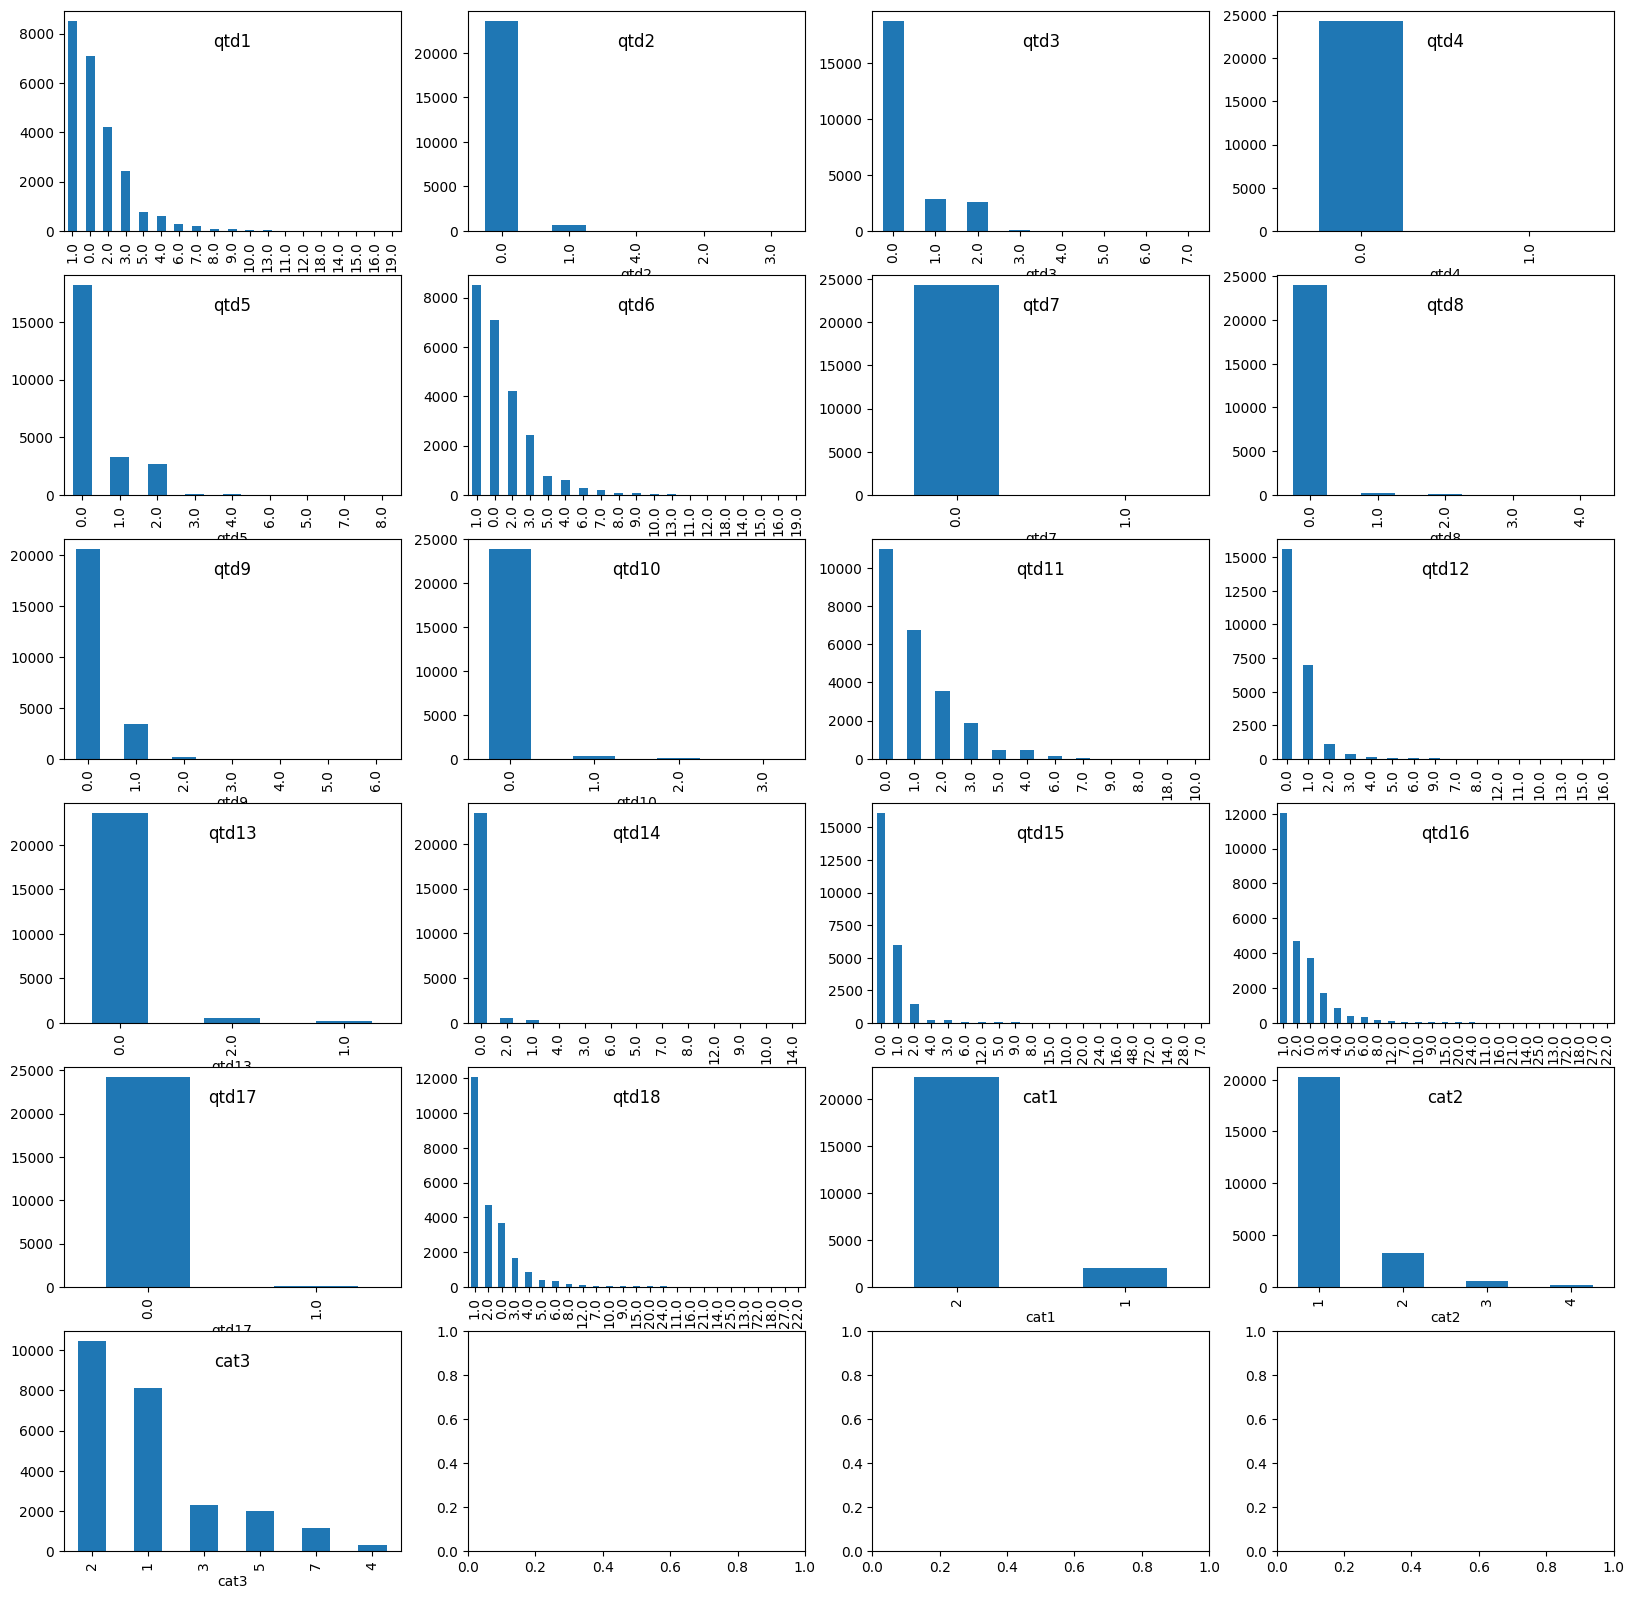

In [ ]:
fig, axs = plt.subplots(linhas, colunas, figsize=(20, 20)) #, sharex='col', sharey='row')

for var, ax in zip(variaveis, axs.flat):

    df_merge[var].value_counts().plot(ax=ax, kind='bar')
    ax.set_title(var, y=0.8)


**Target**

A variável `target` (nossa variável de interesse a ser prevista, indicando risco ou não) é de extrema importância. A tabela de frequência do target é útil para verificarmos o grau de desbalanceamento da nossa base de dados. Em análise de risco, é muito comum que a proporção de eventos 'positivos' (ex: ocorrência de risco) seja muito menor que a de eventos 'negativos' (ex: ausência de risco), o que chamamos de *desbalanceamento de classes*.

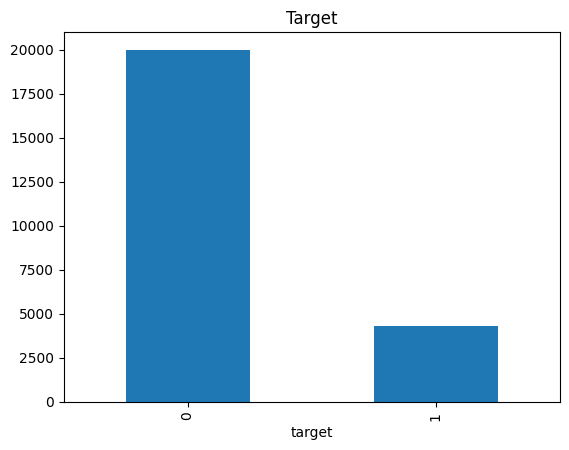

In [ ]:
p = df_merge.target.value_counts().plot(kind='bar', title='Target')

Como é comum em análise de risco, a base é muito desbalanceada para o lado negativo (`target = 0`). Isso significa que a maioria das transações não apresenta o risco. O modelo deverá considerar isso durante o treinamento, utilizando técnicas específicas para lidar com classes desbalanceadas (ex: sobreamostragem, subamostragem, ponderação de classes, métricas de avaliação adequadas).

#### **Análise Bivariada**

Para entender as relações entre as diferentes variáveis do nosso modelo, especialmente como elas se relacionam com a variável `target`, analisaremos a correlação entre elas por meio de uma matriz de correlação. Uma matriz de correlação mostra o coeficiente de correlação entre cada par de variáveis, indicando a força e a direção da relação linear.

Inicialmente, para que possamos calcular a correlação entre todas as variáveis, precisamos converter as variáveis categóricas (`cat1`, `cat2`, `cat3`) em um formato numérico. Faremos isso usando a técnica de *one-hot encoding*, que cria variáveis `dummy` (binárias) para cada categoria. Por exemplo, se `cat1` tem 3 categorias, serão criadas 3 novas colunas (`cat1_1`, `cat1_2`, `cat1_3`), onde 1 indica a presença da categoria e 0 a ausência.

In [ ]:
categ_cols = ['cat1', 'cat2', 'cat3']
df_final=pd.get_dummies(df_merge,columns=categ_cols)
df_final


,v1,v2,bin1,bin2,bin3,bin4,bin5,bin6,bin7,bin8,...,cat2_1,cat2_2,cat2_3,cat2_4,cat3_1,cat3_2,cat3_3,cat3_4,cat3_5,cat3_7
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,True,False,False,False,True,False,False,False,False,False
1,6.981136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,True,False,False,False,True,False,False,False,False,False
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,True,False,False,False,True,False,False,False,False,False
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,True,False,False,False,True,False,False,False,False,False
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24280,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,True,False,False,False,False,True,False,False,False,False
24281,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,True,False,False,False,False,True,False,False,False,False
24282,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,False,True,False,False,False,True,False,False,False,False
24283,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,False,True,False,False,False,True,False,False,False,False


In [ ]:
df_final.columns

Index(['v1', 'v2', 'bin1', 'bin2', 'bin3', 'bin4', 'bin5', 'bin6', 'bin7',
       'bin8', 'bin9', 'bin10', 'bin11', 'bin12', 'bin13', 'bin14', 'bin15',
       'bin16', 'bin17', 'bin18', 'bin19', 'bin20', 'bin21', 'bin22', 'bin23',
       'bin24', 'bin25', 'bin26', 'bin27', 'bin28', 'bin29', 'bin30', 'bin31',
       'qtd1', 'qtd2', 'qtd3', 'qtd4', 'qtd5', 'qtd6', 'qtd7', 'qtd8', 'qtd9',
       'qtd10', 'qtd11', 'qtd12', 'qtd13', 'qtd14', 't1', 't2', 'target',
       'qtd18', 'qtd15', 'qtd16', 'qtd17', 'cat1_1', 'cat1_2', 'cat2_1',
       'cat2_2', 'cat2_3', 'cat2_4', 'cat3_1', 'cat3_2', 'cat3_3', 'cat3_4',
       'cat3_5', 'cat3_7'],
      dtype='object')

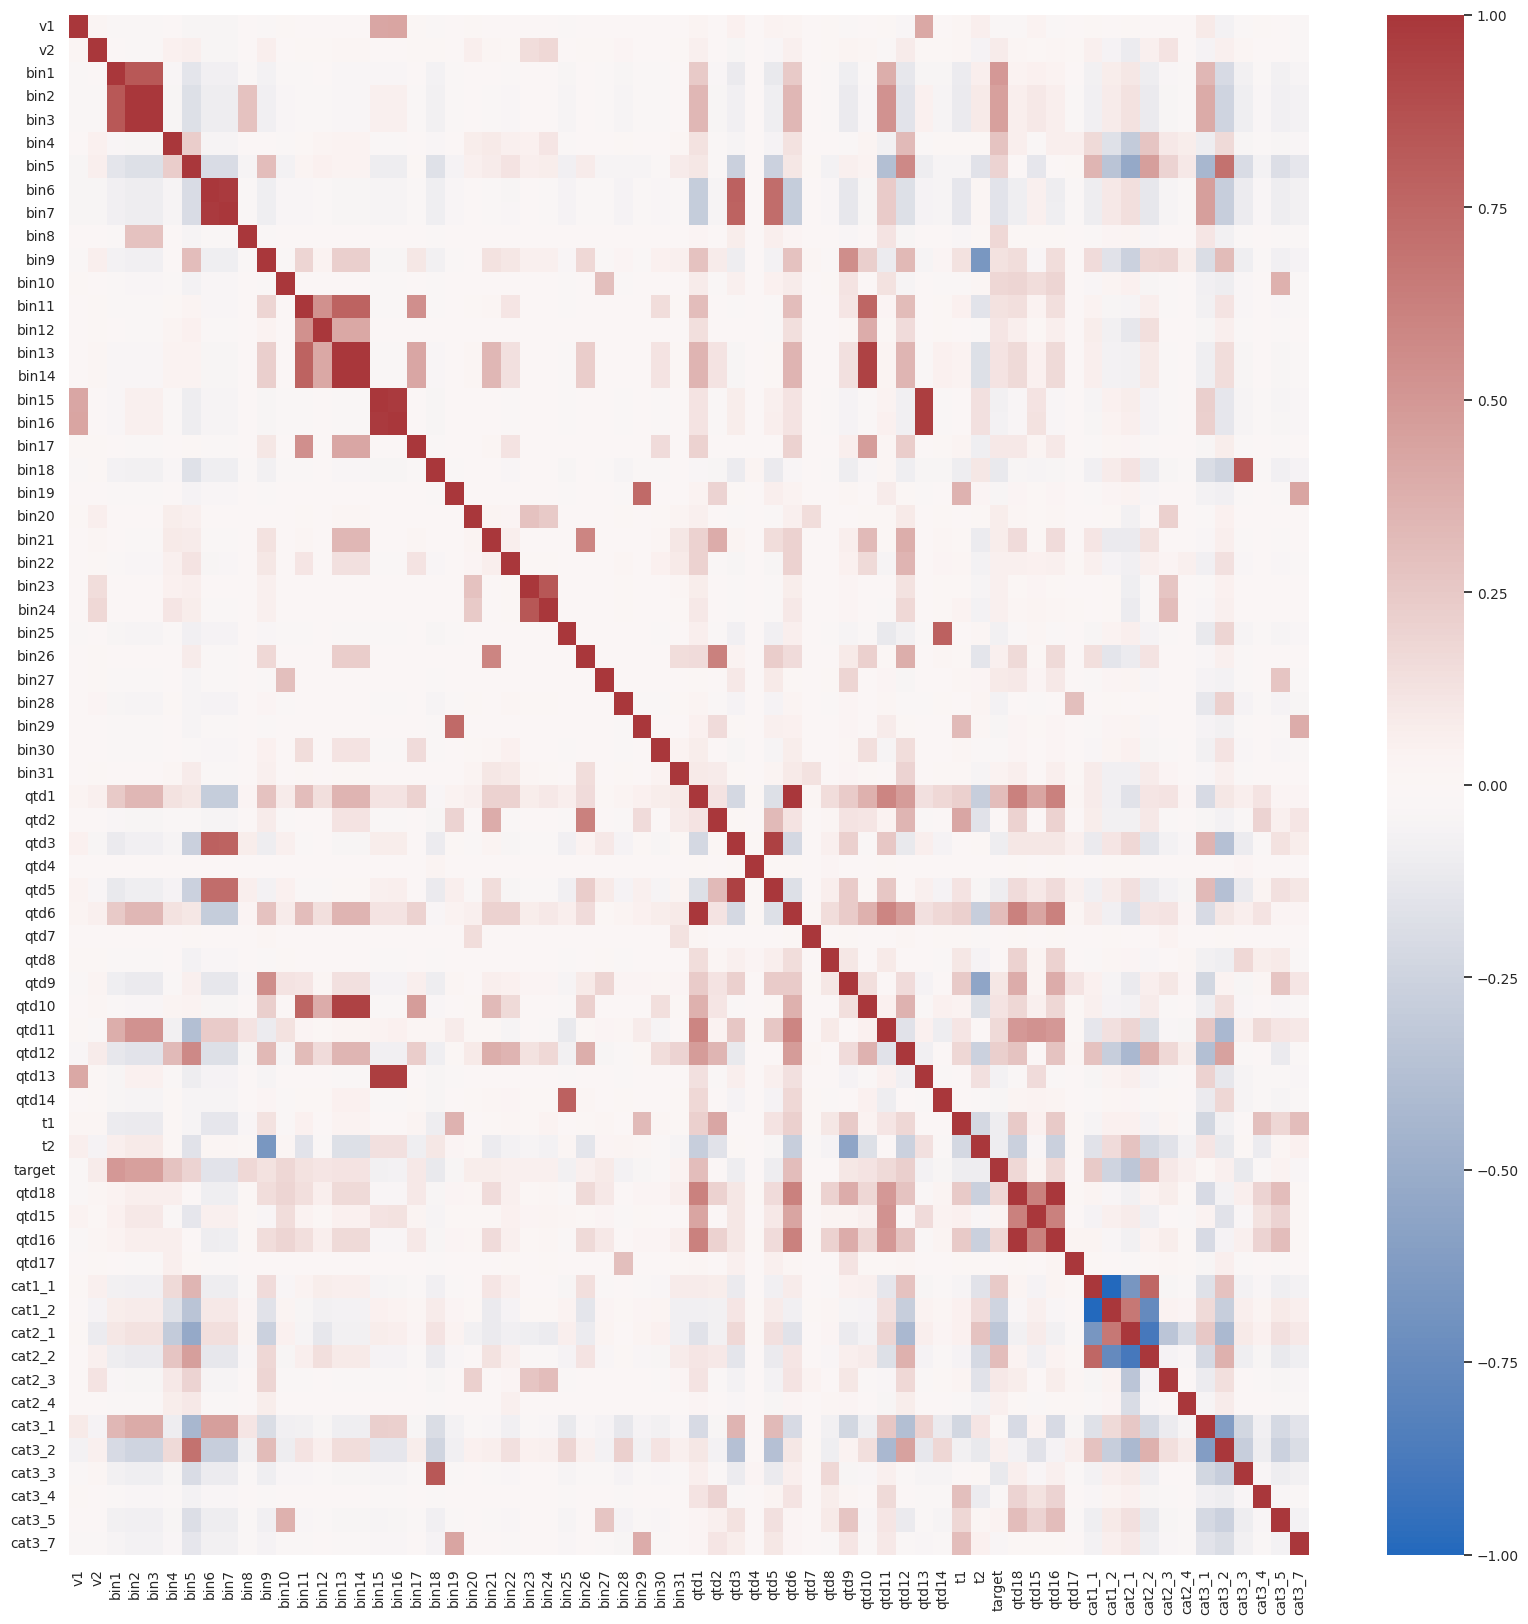

In [ ]:
corrMAtrix = df_final.corr()

import seaborn as sn

sn.set(font_scale=0.9)
sn.heatmap(corrMAtrix, annot=False, cmap='vlag')
plt.rcParams['figure.figsize'] = [20,20]
plt.show()

### Vamos salvar nosso dataset final para usarmos na parte 2 - Treinamento

Após todas as etapas de desnormalização, engenharia de atributos, tratamento de valores faltantes e transformações, o dataset `df_final` está pronto para ser utilizado na próxima etapa, que é o treinamento do modelo. Salvamos este dataframe em formato `pickle` (`.pkl`), que é eficiente para armazenar objetos Pandas, garantindo que o estado atual dos dados, com todos os novos atributos e transformações, possa ser facilmente carregado e reutilizado na Parte 2 do exercício sem a necessidade de reexecutar todas as etapas de preparação.

In [ ]:
del df_final['cod']
df_final.to_pickle(os.path.join(DATA_PATH, "df_final.pkl"))